In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yaml
from scipy.integrate import solve_ivp

from rebinding.efflux_model_collection import *
from rebinding.fig_utils import defaultStyle, save_fig
from tx_fitting import (
    cost_fn,
    load_multi_wash_data,
    load_washout_once_data,
    site_occupancy,
)

defaultStyle(fs=14)

In [5]:
y_data_1, y_data_2, t_eval_1 = load_washout_once_data()
y_data_3, y_data_4, t_eval_2 = load_multi_wash_data()
t_eval = t_eval_1 + t_eval_2
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0_3 = y_data_3[:, 0].mean()
c0_4 = y_data_4[:, 0].mean()
c0 = [c0_1, c0_2, c0_3, c0_4]
c0

[24.013928013339378, 25.07672521576822, 24.294005834354653, 24.040764135602085]

In [7]:
with open("fitting/txFit001/txFit001_res_0421_87d80fea.yaml") as f:
    params_dict = yaml.safe_load(f)["MODEL"]
 

kon, koff, m, mu, k = (
    params_dict["kon"],
    params_dict["koff"],
    params_dict["m"],
    params_dict["mu"],
    params_dict["k"],
)
V1, V2, Vc1, Vc2 = (
    params_dict["V1"],
    params_dict["V2"],
    params_dict["Vc1"],
    params_dict["Vc2"],
)
kd = koff / kon
print(kon, koff, m, mu, k)
print(f"Kd = {kd * 1e3:.3f} nM")

311.95006970542056 37.5453636036586 12.683109266831956 1.0105276193509436 47.77196992098597
Kd = 120.357 nM


In [8]:
s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
s_init_3 = site_occupancy(c0_3, m, kd)
s_init_4 = site_occupancy(c0_4, m, kd)

y0 = [
    (c0_1, 0, s_init_1),
    (c0_2, 0, s_init_1, 0, 10, 0),
    (c0_3, s_init_3),
    (c0_4, 0, s_init_4, 0),
]

In [9]:
sol_1 = solve_ivp(
    washout_once,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k, Vc1, V1),
)
sol_2 = solve_ivp(
    washout_once_comp,
    t_span=[0, 26],
    y0=y0[1],
    args=(kon, koff, m, mu, k, Vc2, V2),
)

In [10]:
sol_3 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[2],
    args=(kon, koff, m, mu),
)
# sol_4 = solve_ivp(
#     washout_zero_bound,
#     t_span=[0, 26],
#     y0=y0[2],
#     args=(0, koff, m, mu),
# )
sol_4 = solve_ivp(
    washout_zero_bound_comp,
    t_span=[0, 26],
    y0=y0[3],
    args=(10, kon, koff, m, mu, k),
)

In [11]:
params = [kon, koff, m, mu, k]
y_data = [y_data_1, y_data_2, y_data_3, y_data_4]
fixed_params = [None] * len(params)
ctrl_params = c0 + [Vc1, V1, Vc2, V2]
factor = [1, 1, 1, 1]
costs, r = cost_fn(
    params, fixed_params, ctrl_params, y_data, t_eval, factor, return_r=True
)

Params: 311.950, 37.545, 12.683, 1.011, 47.772	Residue: 1.27, 1.45, 0.02, 0.32	Total Residue: 3.06


Saving figure taxane_washout


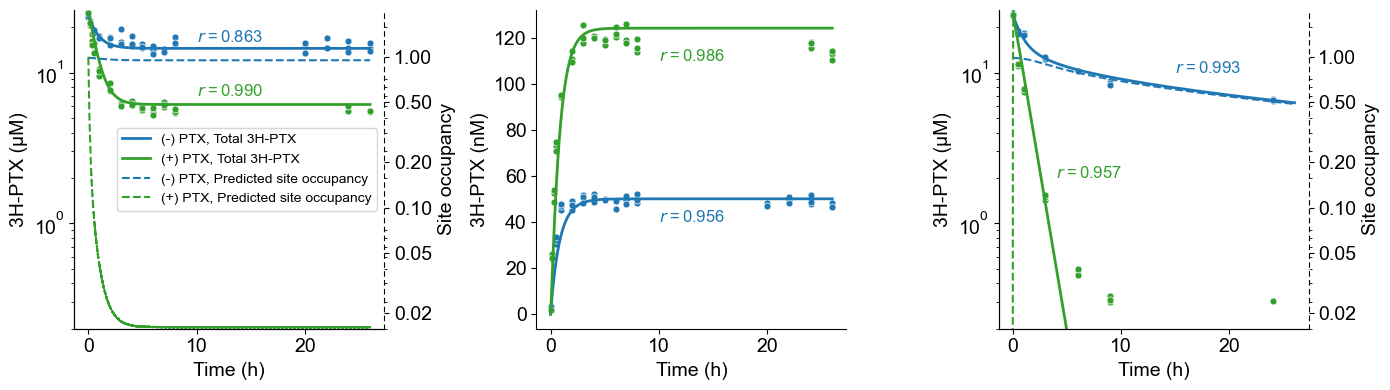

In [12]:
# Plot data with Morandi colors
# Left plot
colors = plt.cm.Paired.colors
primary_color = colors[1]
secondary_color = colors[3]

# Create figure and subplots with better proportions
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4)) # , constrained_layout=True)
# plt.subplots_adjust(wspace=0.3)

ax1.plot(sol_1.t, sol_1.y[0], color=primary_color, lw=2, label="(-) PTX, Total 3H-PTX", alpha=1)
ax1.plot(sol_2.t, sol_2.y[0], color=secondary_color, lw=2, label="(+) PTX, Total 3H-PTX", alpha=1)

ax1_twin = ax1.twinx()
ax1.plot(sol_1.t, sol_1.y[2], ls="--", color=primary_color, lw=1.5, label="(-) PTX, Predicted site occupancy")
ax1.plot(sol_2.t, sol_2.y[2], ls="--", color=secondary_color, lw=1.5, label="(+) PTX, Predicted site occupancy")
ax1.legend(loc="right", fontsize=10)
# ax1_twin.legend(loc="best", fontsize=12)


# Middle plot with better scaling
ax2.plot(sol_1.t, sol_1.y[1] * 1e3, color=primary_color, lw=2)
ax2.plot(sol_2.t, sol_2.y[1] * 1e3, color=secondary_color, lw=2)

# Right plot
ax3.plot(sol_3.t, sol_3.y[0], color=primary_color, lw=2)
ax3.plot(sol_4.t, sol_4.y[0], color=secondary_color, lw=2)


# Right plot twin axis
ax3_twin = ax3.twinx()
ax3_twin.plot(sol_3.t, sol_3.y[1], ls="--", color=primary_color, lw=1.5)
ax3_twin.plot(sol_4.t, sol_4.y[1], ls="--", color=secondary_color, lw=1.5)


# Add scatter points with consistent colors
for i in range(3):
    ax1.scatter(
        x=t_eval_1[0],
        y=y_data_1[i, : len(t_eval_1[0])],
        color=primary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )
    ax1.scatter(
        x=t_eval_1[1],
        y=y_data_2[i, : len(t_eval_1[1])],
        color=secondary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )
    ax2.scatter(
        x=t_eval_1[0],
        y=y_data_1[i, len(t_eval_1[0]) :],
        color=primary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )
    ax2.scatter(
        x=t_eval_1[1],
        y=y_data_2[i, len(t_eval_1[1]) :],
        color=secondary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )
    ax3.scatter(
        x=t_eval_2[0],
        y=y_data_3[i],
        color=primary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )
    ax3.scatter(
        x=t_eval_2[1],
        y=y_data_4[i],# - 0.28,
        color=secondary_color,
        s=25,
        alpha=1,
        edgecolor="white",
        linewidth=0.5,
    )

for bx in [ax1, ax2, ax3]:
    bx.set_xlabel("Time (h)")
    bx.set_ylabel(f"3H-PTX ({'μM' if bx != ax2 else 'nM'})")
    bx.spines["top"].set_visible(False)
    bx.spines["right"].set_visible(False)
    if bx != ax2:
        bx.set_yscale("log")
        bx.set_ylim([2e-1, 26])

for bx_twin in [ax1_twin, ax3_twin]:
    # bx_twin.spines["right"].set_bounds([0, m])
    bx_twin.set_yscale("log")
    bx_twin.spines["top"].set_visible(False)
    bx_twin.spines["right"].set_linestyle((0, (4, 4)))
    bx_twin.set_yticks([m * i for i in [0.02, 0.05, 0.1, 0.2, 0.5, 1]])
    bx_twin.set_ylim([2e-1, 26])
    bx_twin.set_yticklabels([f"{i:.2f}" for i in [0.02, 0.05, 0.1, 0.2, 0.5, 1]])
    bx_twin.tick_params(axis="y")
    bx_twin.set_ylabel("Site occupancy")

# Write r2 score
ax1.text(10, 16, f"$r = ${r[0][0]:.3f}", color=primary_color, fontsize=12)
ax1.text(10, 7, f"$r = ${r[1][0]:.3f}", color=secondary_color, fontsize=12)
ax2.text(10, 40, f"$r = ${r[0][1]:.3f}", color=primary_color, fontsize=12)
ax2.text(10, 110, f"$r = ${r[1][1]:.3f}", color=secondary_color, fontsize=12)
ax3.text(15, 10, f"$r = ${r[2][0]:.3f}", color=primary_color, fontsize=12)
ax3.text(4, 2, f"$r = ${r[3][0]:.3f}", color=secondary_color, fontsize=12)

save_fig("taxane_washout", fmt="png", dpi=300)